Final X shape: (800, 792)

FINAL HYBRID RESULTS
Accuracy: 0.75625
Macro F1: 0.7544643568299482

Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.77      0.80        26
           2       0.73      0.57      0.64        28
           3       0.69      0.89      0.77        27
           4       0.88      0.82      0.85        28
           5       0.71      0.77      0.74        26
           6       0.72      0.72      0.72        25

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.75       160
weighted avg       0.76      0.76      0.75       160



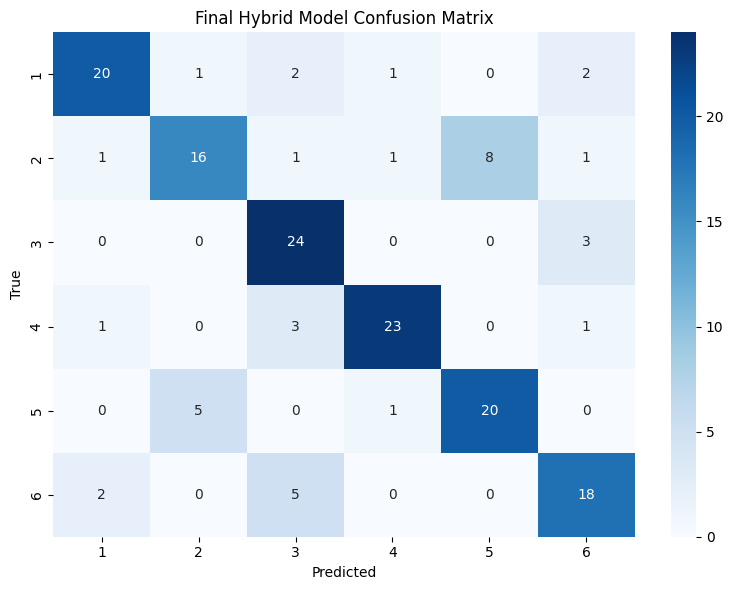


Saved final analysis files.
DONE ✔


In [1]:
# =========================================
# 06 - Final Analysis (THESIS READY VERSION)
# =========================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import seaborn as sns
import matplotlib.pyplot as plt

BASE_PATH = r"C:\Users\Neda\Desktop\personality_llm"

FEATURES_PATH = os.path.join(BASE_PATH, "data", "features")
EMBEDDINGS_PATH = os.path.join(BASE_PATH, "data", "embeddings")
MODELS_PATH = os.path.join(BASE_PATH, "models")
RESULTS_PATH = os.path.join(BASE_PATH, "results")

os.makedirs(RESULTS_PATH, exist_ok=True)

# =========================
# Load model and encoder
# =========================

model = joblib.load(os.path.join(MODELS_PATH, "hybrid_model.pkl"))
label_encoder = joblib.load(os.path.join(MODELS_PATH, "label_encoder.pkl"))

# =========================
# Load original data
# =========================

train_df = pd.read_csv(os.path.join(FEATURES_PATH, "train_features.csv"))

X_style = train_df.drop(
    columns=["text", "label", "clean_text", "tokens"],
    errors="ignore"
)

X_style = X_style.fillna(0).values

X_bert = np.load(os.path.join(EMBEDDINGS_PATH, "train_bert.npy"))

y_raw = train_df["label"].values
y = label_encoder.transform(y_raw)

# =========================
# Safety check
# =========================

assert len(X_style) == len(X_bert), "Mismatch between style and BERT features!"

# =========================
# Feature fusion
# =========================

X = np.hstack([X_style, X_bert])

print("Final X shape:", X.shape)

# =========================
# Recreate same validation split as step 05
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Prediction
# =========================

y_pred = model.predict(X_val)

# =========================
# Metrics
# =========================

acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average="macro")

print("\n====================")
print("FINAL HYBRID RESULTS")
print("====================")
print("Accuracy:", acc)
print("Macro F1:", macro_f1)

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    zero_division=0
))

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Final Hybrid Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_PATH, "final_hybrid_confusion_matrix.png"), dpi=300)
plt.show()

# =========================
# Save final report
# =========================

report_dict = classification_report(
    y_val,
    y_pred,
    target_names=[str(c) for c in label_encoder.classes_],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    os.path.join(RESULTS_PATH, "final_hybrid_classification_report.csv"),
    encoding="utf-8-sig"
)

final_metrics = pd.DataFrame([{
    "model": "Hybrid Style + BERT + XGBoost",
    "accuracy": acc,
    "macro_f1": macro_f1
}])

final_metrics.to_csv(
    os.path.join(RESULTS_PATH, "final_hybrid_metrics.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved final analysis files.")
print("DONE ✔")